# Predição de ativos da bolsa de valores

## Import Libraries

In [31]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.offline import plot
import plotly.graph_objects as go

import datetime
import pandas as pd
from sklearn.utils import class_weight
import utils
from glob import glob

In [32]:
import xgboost as xgb
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, LSTM, MaxPooling1D, Activation, MaxPooling1D, Dropout, Flatten, BatchNormalization, GRU, AveragePooling1D, SpatialDropout1D, GlobalAveragePooling1D
#from tensorflow.keras.initializers import he_uniform
from tensorflow import keras
import tensorflow_addons as tfa

In [33]:
import tensorflow as tf

print("Versão do TensorFlow:", tf.__version__)
print("GPUs disponíveis:", tf.config.list_physical_devices('GPU'))

Versão do TensorFlow: 2.15.0
GPUs disponíveis: []


In [34]:
import os, sys
processing_source_path = os.path.abspath('Processing/')
if(processing_source_path not in sys.path):
    sys.path.append(processing_source_path)
from DataLoaderPipeline import scrapingHistoricalData, FeaturesDataGenerator

import  ProcessingPipeline as pp


## Init parameters

In [35]:
# features and dataloader parameters
features_indicators=['Close', 'Open', 'High', 'Low', 
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14',
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC', ]
                    #'Volume_log','Chaikin_Money_Flow', 'Williams_R,'PPO',]


# features and dataloader parameters
features_indicators=['Close', 'Open', 'High', 'Low',
                    
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350',
 
                    'RSI_14' ,
                    'MACD', 'MACD_Signal', 'MACD_Histogram',
 
                    'Stochastic_K', 'Stochastic_D',
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC']  

features_indicators=[ 'Close', 'Open', 'High', 'Low', 'Volume','Volume_log',
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14', 
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC', 'Chaikin_Money_Flow']

features_indicators=['SCP', 'RSI_14', 'Williams_R', 'MFI','MACD',
                     'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350',
                     'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                     'CCI',  'ROC', 'Chaikin_Money_Flow']
 



features_indicators=['SCP', 'RSI_14', 'Williams_R', 'MFI','MACD',
                     'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350',
                     'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                     'CCI',  'ROC', 'Chaikin_Money_Flow']

#features_indicators=['SCP', 'RSI_14', 'Williams_R', 'MFI','MACD']


In [36]:


features_indicators=['Close','SCP', 'RSI_14', 'Williams_R', 'MFI','MACD',
                     'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350',
                     'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                     'CCI',  'ROC', 'Chaikin_Money_Flow']

#pred_days = 60
#pred_days = 30
pred_days = 40
buy_sell_threshold=[0.05,-0.05]
#lookback = 20
#lookback = 60
lookback = 40# 30 # 40

batch_size = 128
shuffle = False
data_augmentation =True

min_norm=-1
max_norm=1

trade=['Hold','Buy','Sell']

# model parameters
input_shape = (lookback, len(features_indicators))
n_classes = len(trade)



In [37]:
SHD=scrapingHistoricalData()
date_now = datetime.date.today()
cryptos_df = SHD.get_crypto_historical_data(['BTC'], '4h', '2018-01-01', date_now.strftime('%Y-%m-%d'))

split_data=FeaturesDataGenerator().split_data
X_train, X_val, T_train, T_val=split_data(cryptos_df['Close'].values, cryptos_df['Date'], factor=0.80)
X_val, X_test, T_val, T_test=split_data(X_val.T, T_val, factor=0.5)

X_data_gen_train = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_train)].iloc[:,:], datatype='2D', predict_type='both', lookback = lookback, pred_days = pred_days, buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=data_augmentation, min_max_norm_features=[min_norm, max_norm])


self.pred_days 1
input data shape (19, 1, 30)
output data shape (19, 3)
self.pred_days 40


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\MarketIndicators.py:97: RuntimeWarning:

invalid value encountered in divide



input data shape (24388, 40, 19)
output data shape (24388, 3)


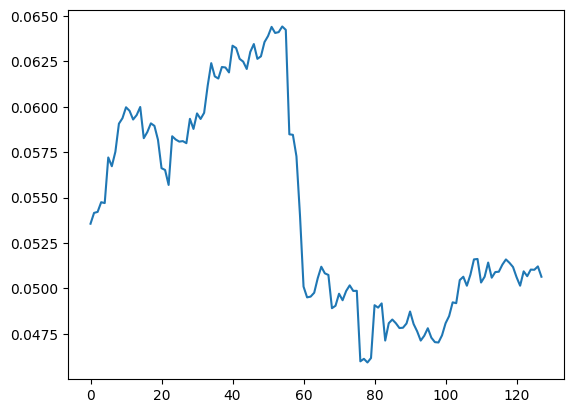

In [38]:
plt.plot(X_data_gen_train[10][1][0])

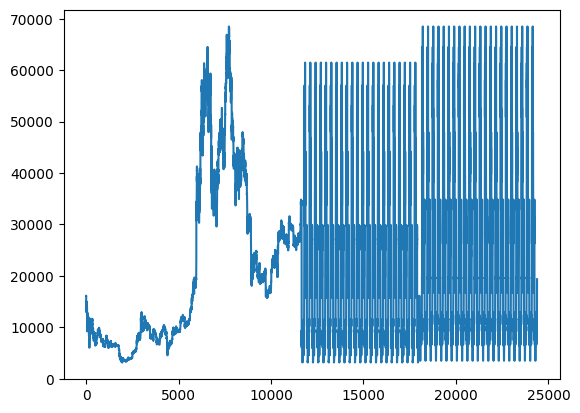

In [39]:
plt.plot(X_data_gen_train.features[:,-1,0])
plt.show()

In [40]:
Y_train_categorical=np.argmax(X_data_gen_train.y_classification,axis=1)

n_classes, counts=np.unique(Y_train_categorical, return_counts=True) 
print(n_classes, counts)
output_class_weights = class_weight.compute_class_weight('balanced', classes=n_classes, y=np.argmax(X_data_gen_train.y_classification,axis=1))

print(output_class_weights)

# Formula used - Naive method where
# weight = 1 - (no. of samples present / total no. of samples)
# So more the samples, lower the weight

weight_dict = {k: (1 - (v / counts.sum())) for k, v in enumerate(counts)}
print(weight_dict)


[0 1 2] [11086  6651  6651]
[0.73329725 1.22227234 1.22227234]
{0: 0.5454321797605379, 1: 0.727283910119731, 2: 0.727283910119731}


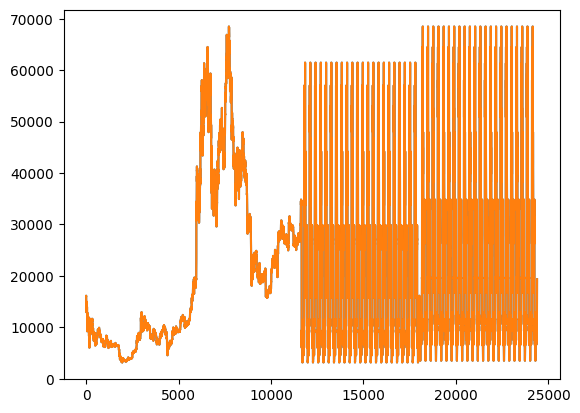

In [41]:

plt.plot(X_data_gen_train.window_close_values)
plt.plot(X_data_gen_train.features[:,-1,0])

## Deep Learning Model

In [42]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Dense, Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

In [43]:
input_shape

(40, 19)

In [44]:
# Camadas comuns em 2D
def common_layers(input_layer, dropout_rate):
    x = Conv2D(64, kernel_size=(1, 2), activation='relu', padding='same')(input_layer)
    x = MaxPooling2D(pool_size=(1, 2))(x)
    x = Conv2D(128, kernel_size=(1, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(1, 2))(x)
    return x


# Camada head em 2D
def head_layer(conv_layer, num_classes, dropout_rate, activation='linear', output_name=None):
    x = Flatten()(conv_layer)
    # Camadas densas com regularização L2
    x = Dense(256, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(num_classes,  activation=activation, name=output_name)(x)
    return x


# Criando o modelo completo
def create_model_2d(input_shape, num_classes, dropout_rate=0.2):
    input_layer = Input(shape=input_shape)

    # Camadas comuns
    features = common_layers(input_layer, dropout_rate)

    # Head de classificação
    classification_output = head_layer(
        features, 
        num_classes=num_classes, 
        dropout_rate=dropout_rate, 
        activation='softmax', 
        output_name='classification_head'
    )

    # Modelo final
    model = Model(inputs=input_layer, outputs=[classification_output], name="CNN_MultiHead_2D")
    return model


# Definindo parâmetros
input_shape_model = (1, input_shape[1], input_shape[0])  # Exemplo: imagens RGB de 128x128
num_classes = 3
dropout_rate = 0.3

# Criando o modeloa
model_CNN_MultiHead = create_model_2d(input_shape_model, num_classes, dropout_rate)

# Resumo do modelo
list_of_models=[model_CNN_MultiHead]
model_CNN_MultiHead.summary()

Model: "CNN_MultiHead_2D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 1, 19, 40)]       0         
                                                                 
 conv2d_5 (Conv2D)           (None, 1, 19, 64)         5184      
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 1, 9, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 1, 9, 128)         24704     
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 1, 4, 128)         0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 512)          

In [45]:
from tensorflow.keras.layers import Reshape, GlobalAveragePooling2D

# Camadas comuns em 2D
def common_layers(input_layer, dropout_rate):
    x = Conv2D(64, (3, 3), padding="same")(input_layer)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=1, padding="same")(x)
    x = Dropout(dropout_rate)(x)

    x = Conv2D(128, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=2, padding="same")(x)
    x = Dropout(dropout_rate)(x)

    return x


# Camada head em 2D
def head_layer(conv_layer, num_classes, dropout_rate, l2_regularization, activation='linear', output_name=None):
    x = Conv2D(256, (3, 3), padding="same")(conv_layer)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=2, padding="same")(x)
    x = Dropout(dropout_rate)(x)

    # Global Average Pooling para reduzir a dimensionalidade espacial
    #x = GlobalAveragePooling2D()(attention_output)  # (batch_size, channels)

    x = Flatten()(x)
    #x = Flatten()(x)
    # Camadas densas com regularização L2
    x = Dense(256, kernel_regularizer=l2(l2_regularization))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(128, kernel_regularizer=l2(l2_regularization))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(num_classes)(x)
    x = Activation(activation, name=output_name)(x)

    return x


# Criando o modelo completo
def create_model_2d(input_shape, num_classes, dropout_rate=0.2, l2_regularization=0.01):
    input_layer = Input(shape=input_shape)

    # Camadas comuns
    features = common_layers(input_layer, dropout_rate)

    # Head de classificação
    classification_output = head_layer(
        features, 
        num_classes=num_classes, 
        dropout_rate=dropout_rate, 
        l2_regularization=l2_regularization, 
        activation='softmax', 
        output_name='classification_head'
    )

    # Modelo final
    model = Model(inputs=input_layer, outputs=[classification_output], name="CNN_MultiHead_2D")
    return model


# Definindo parâmetros
input_shape_model = (1, input_shape[1], input_shape[0])  
num_classes = 3
dropout_rate = 0.3
l2_regularization = 0.01

# Criando o modeloa
model_CNN_MultiHead = create_model_2d(input_shape_model, num_classes, dropout_rate, l2_regularization)

# Resumo do modelo
model_CNN_MultiHead.summary()
list_of_models=[model_CNN_MultiHead]

Model: "CNN_MultiHead_2D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 1, 19, 40)]       0         
                                                                 
 conv2d_7 (Conv2D)           (None, 1, 19, 64)         23104     
                                                                 
 batch_normalization_5 (Bat  (None, 1, 19, 64)         256       
 chNormalization)                                                
                                                                 
 activation_5 (Activation)   (None, 1, 19, 64)         0         
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 1, 19, 64)         0         
 g2D)                                                            
                                                                 
 dropout_7 (Dropout)         (None, 1, 19, 64)    

In [46]:
#Metrics and Loss Functions  

from tensorflow.keras import backend as K

def matthews_correlation_coefficient(y_true, y_pred):
    tp = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    fp = K.sum(K.round(K.clip((1 - y_true) * y_pred, 0, 1)))
    fn = K.sum(K.round(K.clip(y_true * (1 - y_pred), 0, 1)))

    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / K.sqrt(den + K.epsilon())

def R2(y_true, y_pred): # squareds Pearson's correlation coef 
    SS_res =  K.sum(K.square( y_true-y_pred ))
    SS_tot = K.sum(K.square( y_true - K.mean(y_true) ) )
    return ( 1 - SS_res/(SS_tot - K.epsilon()) )

def NRMSE(y_true, y_pred): # normalized_root_mean_squared_error
    return 1-K.sqrt(K.mean(K.square(y_pred - y_true))) 

MSE= tf.keras.losses.mean_squared_error
MAE = tf.keras.losses.mean_absolute_error
MAPE = tf.keras.losses.mean_absolute_percentage_error

In [47]:
#Optimizers
def get_optimizer():
    optimizer1 = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, amsgrad=True, name="Adam")
    #optimizer1 = tf.keras.optimizers.RMSprop(learning_rate=0.001)
    #optimizer = optimizers.SGD(lr=params["lr"], decay=1e-6, momentum=0.9, nesterov=True)

    return optimizer1
    #

#Train options callbacks

    # Avalia se está tendo avanção de desempenho no treinamento/validação e para caso não tenha avanço 
EarlyStopping=tf.keras.callbacks.EarlyStopping( monitor="val_loss", patience=20, verbose=1, mode="min", restore_best_weights=True,)

    # verifica se está tendo avanço de desempenho durante o treinamento, caso não reduz integralmente o lr
reduceLr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor = 0.01, patience = 5, min_lr=1e-20,verbose=1)



def checkpoints(model_name):
    checkpoint_filepath =f'models/model_{model_name}_crypto_lookback_{lookback}'
    csvLogger = tf.keras.callbacks.CSVLogger(checkpoint_filepath+'_history.csv', separator=',',append=True)
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, verbose=1, save_weights_only=False, monitor='val_loss', mode='min', save_best_only=True)
    print("Training model :", checkpoint_filepath)

    return csvLogger, model_checkpoint_callback

model_name = 'CNN_MultiHead_2D'

In [48]:
f'models/model_{model_name}_crypto_lookback_{lookback}'

'models/model_CNN_MultiHead_2D_crypto_lookback_40'

In [49]:
list_of_models=[model_CNN_MultiHead]

## Load Data And train

In [50]:
SHD=scrapingHistoricalData()

# Lista de criptomoedas
interval = '4h'#


In [51]:
import datetime
init_date = '2017-01-01'
#init_date = '2020-01-01'
init_date_object = datetime.datetime.strptime(init_date, '%Y-%m-%d').date()

date_now = datetime.date.today()

diff_years = date_now.year - init_date_object.year
year_window = 8


#cryptos_list = [ 'BTC','ETH','SOL','DOT','FET']/ 
cryptos_list = ['BTC']

if year_window > diff_years:
    raise ValueError("O intervalo de anos (year_window) é maior do que o período disponível nos dados.")


In [52]:
idx=0
for i, cryptos in enumerate(cryptos_list):

    for stride_year in range(0, diff_years-year_window+1):
        init_time=f'{init_date_object.year+stride_year}-01-01'

        look_year=init_date_object.year+stride_year+year_window
        if date_now.year == look_year:
            end_time=date_now.strftime('%Y-%m-%d')
        else:
            end_time=f'{look_year}-01-01'
        print(f'{cryptos} Dataset Period:{init_time} : {end_time}') 

        # Caminho do arquivo
        #file_folder = f'Data_history/{cryptos_list[0]}_{interval}_{init_time}_{end_time}.csv'
        file_folder = [crypto_data for crypto_data in glob("Data_history/*")  if cryptos in crypto_data][0]
        if os.path.exists(file_folder):
            print(f"The file {file_folder} exist in folder path.")
            cryptos_df=pd.read_csv(file_folder, index_col=0)

            #mask = (cryptos_df['Date'] >= init_time) & (cryptos_df['Date'] <= end_time)
            #cryptos_df = cryptos_df[mask]
            
            #cryptos_df.reset_index(drop=True, inplace=True)
            #cryptos_df.to_csv(file_folder)
            #print(f"Save the file {file_folder} in folder path.")
        else:
            print(f"Donwload the file {file_folder} from bincance history.")
            # Obtenha os dados históricos
            cryptos_df = SHD.get_crypto_historical_data([cryptos], interval, init_time, end_time)
        
        # split the data in train validation and test
        split_data=FeaturesDataGenerator().split_data
        X_train, X_val, T_train, T_val=split_data(cryptos_df['Close'].values, cryptos_df['Date'], factor=0.80)
        X_val, X_test, T_val, T_test=split_data(X_val.T, T_val, factor=0.5)

        print('Train data shape',X_train.shape)
        print('Vall data shape',X_val.shape)
        print('Test data shape',X_test.shape)

        # get train vall and test dataloader
        X_data_gen_train = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_train)].iloc[:,:], datatype='2D', lookback = lookback, pred_days = pred_days, buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=data_augmentation, min_max_norm_features=[min_norm, max_norm])
        X_data_gen_val = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_val)].iloc[:,:], datatype='2D', lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=data_augmentation, min_max_norm_features=[min_norm, max_norm])
        X_data_gen_test = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_test)].iloc[:,:], datatype='2D', lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= False, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm_features=[min_norm, max_norm])

        # get classes weigths 
        Y_train_categorical=np.argmax(X_data_gen_train.y_classification,axis=1)
        n_classes, counts=np.unique(Y_train_categorical, return_counts=True) 
        print(n_classes, counts)
        output_class_weights = class_weight.compute_class_weight('balanced', classes=n_classes, y=np.argmax(X_data_gen_train.y_classification,axis=1))

        #print(output_class_weights)
        #output_class_weights = np.ones(3) 
        #weighted_categorical_crossentropy_loss= X_data_gen_train.weighted_categorical_crossentropy(output_class_weights)

        penalty_matrix = np.array([
            [0.0, 1.0, 1.0],  # Penalidade para classificar Hold como Buy ou Sell
            [0.5, 0.0, 2.0],  # Penalidade para classificar Buy como Hold (0.5) ou Sell (2.0)
            [0.5, 2.0, 0.0]   # Penalidade para classificar Sell como Hold (0.5) ou Buy (2.0)
        ])
        weighted_categorical_crossentropy_loss= X_data_gen_train.custom_weighted_categorical_crossentropy(output_class_weights, penalty_matrix)
        
        #weight_dict = {k: (1 - (v / counts.sum())) for k, v in enumerate(counts)}
        loss = weighted_categorical_crossentropy_loss
        #loss = X_data_gen_train.focal_loss(gamma=2.0, alpha=0.25)
        #loss = keras.losses.CategoricalCrossentropy()
        
        for idx_model, model in enumerate(list_of_models):

            if idx == 0:  
                optimizer = get_optimizer()
                csvLogger, model_checkpoint_callback  = checkpoints(model._name)
                model.compile(loss=[loss], optimizer=optimizer, metrics=['accuracy', tfa.metrics.F1Score(num_classes=3, average='weighted'),matthews_correlation_coefficient])
                idx=1
            else:
                optimizer = get_optimizer()
                csvLogger, model_checkpoint_callback  = checkpoints(model._name)
                model = trained_best_models[model._name]
                model.compile(loss=[loss], optimizer=optimizer, metrics=['accuracy',matthews_correlation_coefficient])




            print('------------------------------------------------------------------------------------------------------------------------------------------------------------------------')
            print(f'Initing train for model: {model._name}')

            history = model.fit(
                X_data_gen_train,
                epochs=200,
                callbacks=[EarlyStopping, reduceLr, model_checkpoint_callback, csvLogger],
                validation_data=X_data_gen_val,
                #shuffle=True,
                #class_weight=weight_dict,
                #class_weight=dict(enumerate([1, 1, 1])),
                verbose=2
            )
            # Assuming history_metric, history_metric_val, history are defined elsewhere

            fig, axes = plt.subplots(2, 1, figsize=(15, 8))  # Create subplots programmatically

            # Plot accuracy, sharing x-axis with NRMSE
            axes[0].plot(history.history['accuracy'])
            axes[0].plot(history.history['val_accuracy'])
            axes[0].set_title(f'{model._name}: Accuracy')
            axes[0].set_ylabel('Accuracy')
            axes[0].set_xlabel('Epoch')  # Shared x-axis label
            axes[0].legend(['train', 'validation'], loc='upper left')

            # Plot loss
            axes[1].plot(history.history['loss'])
            axes[1].plot(history.history['val_loss'])
            axes[1].set_title(f'{model._name}: Loss (categorical_crossentropy)')
            axes[1].set_ylabel('Loss')

            # Adjust spacing and margins (optional)
            plt.subplots_adjust(left=0.1, bottom=0.15, right=0.9, top=0.9, wspace=0.2)

            # Fine-tune spacing (optional)
            plt.tight_layout()

            plt.show()
        trained_best_models={}
        print("---------------------------------------------------------------------------------------------------------------------------------")
        for model in list_of_models:
            print(model.name)
            checkpoint_filepath =f'models/model_{model_name}_crypto_lookback_{lookback}'
            trained_best_models[f'{model._name}']=tf.keras.models.load_model(
                checkpoint_filepath, 
                custom_objects={'loss': weighted_categorical_crossentropy_loss, 'matthews_correlation_coefficient': matthews_correlation_coefficient}, 
                compile=False)

            print('Model name:',model_name)

            x_data=X_data_gen_test.apply_NomrMinmax(X_data_gen_test.features, min_norm, max_norm, axis=0)
            x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])
            
            label_pred = trained_best_models[model_name].predict(x_data)
            print(model_name,' classification Accuracy',
                            utils.f1_score(np.argmax(X_data_gen_test.y_classification,axis=1),
                            np.argmax(label_pred,axis=1),average="micro"))

            cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_test.y_classification,axis=1),np.argmax(label_pred,axis=1))
            
            try:
                utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
            except:
                print(cf_matrix)


BTC Dataset Period:2017-01-01 : 2025-04-18
The file Data_history\BTC_4h_2017-08-17_2025-02-27.csv exist in folder path.
self.pred_days 1
input data shape (19, 1, 30)
output data shape (19, 3)
Train data shape (12141,)
Vall data shape (1518,)
Test data shape (1519,)
self.pred_days 40


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\MarketIndicators.py:97: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:669: RuntimeWarning:

divide by zero encountered in log



input data shape (25326, 40, 19)
output data shape (25326, 3)
self.pred_days 40
input data shape (3092, 40, 19)
output data shape (3092, 3)
self.pred_days 40
input data shape (1479, 40, 19)
output data shape (1479, 3)
[0 1 2] [11512  6907  6907]
[0.73332175 1.22223831 1.22223831]
Training model : models/model_CNN_MultiHead_2D_crypto_lookback_40
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train for model: CNN_MultiHead_2D
Epoch 1/200



Epoch 1: val_loss improved from inf to 6.90145, saving model to models\model_CNN_MultiHead_2D_crypto_lookback_40
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_lookback_40\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_lookback_40\assets


197/197 - 38s - loss: 7.8815 - accuracy: 0.2974 - f1_score: 0.2721 - matthews_correlation_coefficient: -5.1778e-02 - val_loss: 6.9014 - val_accuracy: 0.3418 - val_f1_score: 0.2044 - val_matthews_correlation_coefficient: 0.0000e+00 - lr: 1.0000e-04 - 38s/epoch - 192ms/step
Epoch 2/200

Epoch 2: val_loss improved from 6.90145 to 5.63483, saving model to models\model_CNN_MultiHead_2D_crypto_lookback_40
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_lookback_40\assets


...

INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_lookback_40\assets


197/197 - 21s - loss: 0.8240 - accuracy: 0.8447 - f1_score: 0.8423 - matthews_correlation_coefficient: 0.7224 - val_loss: 1.3670 - val_accuracy: 0.4567 - val_f1_score: 0.2539 - val_matthews_correlation_coefficient: 0.1501 - lr: 1.0000e-04 - 21s/epoch - 107ms/step
Epoch 28/200

Epoch 28: val_loss did not improve from 1.36697
197/197 - 17s - loss: 0.7882 - accuracy: 0.8530 - f1_score: 0.8505 - matthews_correlation_coefficient: 0.7425 - val_loss: 1.4548 - val_accuracy: 0.3975 - val_f1_score: 0.2601 - val_matthews_correlation_coefficient: 0.1090 - lr: 1.0000e-04 - 17s/epoch - 88ms/step
Epoch 29/200

Epoch 29: val_loss did not improve from 1.36697
197/197 - 21s - loss: 0.7501 - accuracy: 0.8683 - f1_score: 0.8658 - matthews_correlation_coefficient: 0.7662 - val_loss: 1.3769 - val_accuracy: 0.4134 - val_f1_score: 0.2613 - val_matthews_correlation_coefficient: 0.1150 - lr: 1.0000e-04 - 21s/epoch - 109ms/step
Epoch 30/200

Epoch 30: val_loss did not improve from 1.36697
197/197 - 15s - loss: 0

INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_lookback_40\assets


197/197 - 24s - loss: 0.6537 - accuracy: 0.8965 - f1_score: 0.8938 - matthews_correlation_coefficient: 0.8167 - val_loss: 1.3515 - val_accuracy: 0.4521 - val_f1_score: 0.2534 - val_matthews_correlation_coefficient: 0.1556 - lr: 1.0000e-04 - 24s/epoch - 123ms/step
Epoch 33/200

Epoch 33: val_loss did not improve from 1.35154
197/197 - 19s - loss: 0.6277 - accuracy: 0.9052 - f1_score: 0.9016 - matthews_correlation_coefficient: 0.8314 - val_loss: 1.3800 - val_accuracy: 0.4574 - val_f1_score: 0.2542 - val_matthews_correlation_coefficient: 0.1430 - lr: 1.0000e-04 - 19s/epoch - 98ms/step
Epoch 34/200

Epoch 34: val_loss did not improve from 1.35154
197/197 - 22s - loss: 0.5994 - accuracy: 0.9125 - f1_score: 0.9103 - matthews_correlation_coefficient: 0.8451 - val_loss: 1.3976 - val_accuracy: 0.4544 - val_f1_score: 0.2544 - val_matthews_correlation_coefficient: 0.1324 - lr: 1.0000e-04 - 22s/epoch - 111ms/step
Epoch 35/200

Epoch 35: val_loss did not improve from 1.35154
197/197 - 16s - loss: 0

KeyboardInterrupt: 

In [ ]:
checkpoint_filepath

'models/model_CNN_MultiHead_2D_crypto_lookback_40'

In [ ]:
output_class_weights

array([1., 1., 1.])

### Vall Data 

Model name: CNN_MultiHead_2D
97/97 [==============================] - 1s 9ms/step
CNN_MultiHead_2D  classification Accuracy 0.6691461836998707


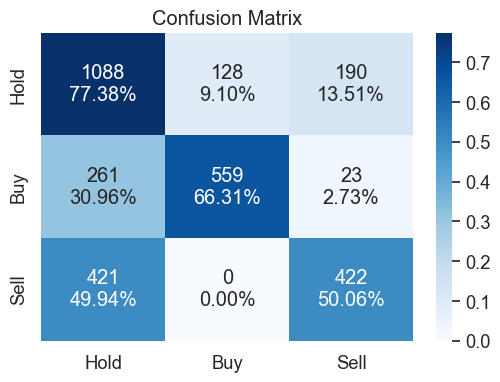

In [ ]:
model_name = "CNN_MultiHead_2D"  
print('Model name:',model_name)

x_data=X_data_gen_val.apply_NomrMinmax(X_data_gen_val.features, min_norm,  max_norm, axis=0)
x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])

label_pred = trained_best_models[model_name].predict(x_data)
print(model_name,' classification Accuracy',
                utils.f1_score(np.argmax(X_data_gen_val.y_classification,axis=1),
                np.argmax(label_pred,axis=1),average="micro"))

cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_val.y_classification,axis=1),np.argmax(label_pred,axis=1))
 
try:
    utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
except:
    print(cf_matrix)

### Backtest

In [ ]:
# Classe para gerenciar o backtesting
import matplotlib.pyplot as plt

class Backtester:
    def __init__(self, initial_balance, data, transaction_cost=0.000001):
        self.initial_balance = initial_balance
        self.data = data
        self.balance = initial_balance
        self.position = 0
        self.portfolio_value = []
        self.transaction_cost = transaction_cost
        self.trades = []

    def execute_trade(self, signal, price):
        if signal == 'Buy':
            if self.balance > 0:
                cost = self.balance * self.transaction_cost
                self.position = (self.balance - cost) / price
                self.trades.append({'Action': 'Buy', 'Price': price, 'Position': self.position})
                self.balance = 0
        
        elif signal == 'Sell':
            if self.position > 0:
                proceeds = self.position * price
                cost = proceeds * self.transaction_cost
                self.balance = proceeds - cost
                self.trades.append({'Action': 'Sell', 'Price': price, 'Balance': self.balance})
                self.position = 0

        elif signal not in ['Hold']:
            print('balance:',self.balance)
            print('positi:',self.position)
            raise ValueError(f"Invalid signal: {signal}")

    def run(self, signals):
        for i in range(len(self.data)):
            price = self.data['Close'].iloc[i]
            signal = signals[i]
            self.execute_trade(signal, price)
            portfolio_value = self.balance + (self.position * price)
            self.portfolio_value.append(portfolio_value)

    def plot_portfolio_value(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.portfolio_value, label='Portfolio Value')
        plt.title('Portfolio Value Over Time')
        plt.xlabel('Time')
        plt.ylabel('Portfolio Value')
        plt.legend()
        plt.show()

    def calculate_metrics(self):
        final_portfolio_value = self.portfolio_value[-1]
        roi = (final_portfolio_value - self.initial_balance) / self.initial_balance * 100
        max_drawdown = min(self.portfolio_value) / self.initial_balance - 1
        return {
            'Final Portfolio Value': final_portfolio_value,
            'ROI (%)': roi,
            'Max Drawdown (%)': max_drawdown * 100
        }

# Função para gerar sinais fictícios
def generate_signals(signals):
    trade_signals = ['Hold']
    for i in range(1,len(signals)):
        if signals[i] == 'Buy' and signals[i-1] == 'Buy':
            trade_signals.append('Hold')
        elif signals[i] == 'Buy' and signals[i-1] == 'Hold':
            trade_signals.append('Buy')
        elif signals[i] == 'Sell' and signals[i-1] == 'Sell':
            trade_signals.append('Hold')
        elif signals[i] == 'Sell' and signals[i-1] == 'Hold':
            trade_signals.append('Sell')
        else:
            trade_signals.append('Hold')


    return trade_signals

self.pred_days 40
input data shape (10492, 40, 18)
output data shape (10492, 3)
328/328 [==============================] - 3s 9ms/step
(array(['Buy', 'Hold', 'Sell'], dtype='<U4'), array([1136, 8157, 1199], dtype=int64))


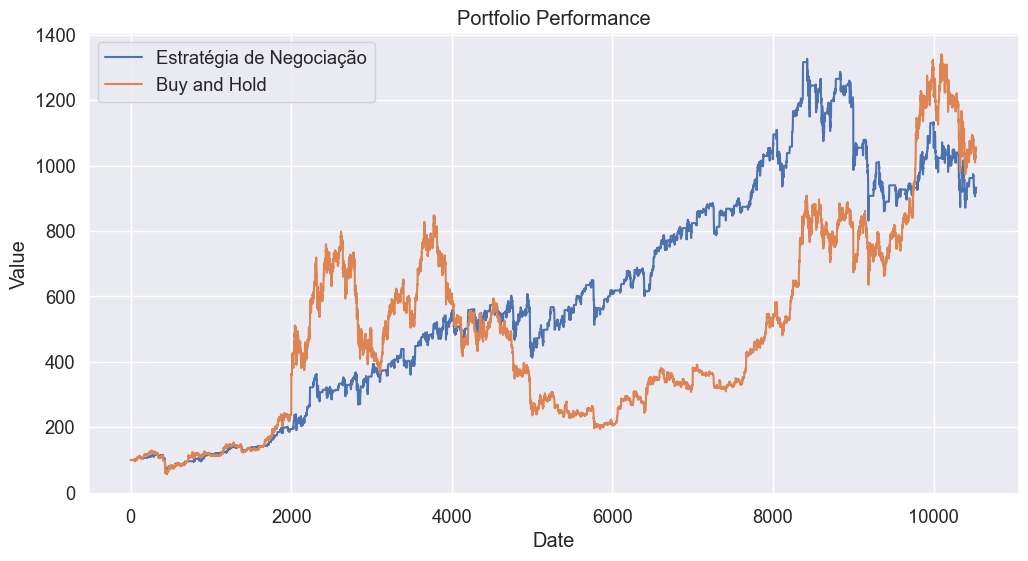

Retorno da Estratégia de Negociação: 832.82%
Retorno da Estratégia de Buy and Hold: 950.97%


In [ ]:
# Parâmetros iniciais
symbol=['BTC']
#symbol = cryptos_list[0]
interval = '4h' 
start_time = '2020-01-01'
initial_balance = 100

# Coleta de dados
data = SHD.get_crypto_historical_data(symbol, interval, start_time)

dataGen_inference = FeaturesDataGenerator(data, datatype = '2D', lookback = lookback, pred_days = pred_days, shuffle= False, batch_size=1, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])
if data.empty:
    print("Nenhum dado encontrado.")
else:
    # Geração de sinais e backtesting

    x_data_inference=dataGen_inference.comput_features(data, pred_days=0)
    x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)
    x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])
    
    # list_of_models = ['MLP', 'GRU', 'CNN_LSTM_MultiHead', 'CNN_MultiHead', 'LSTM', 'LSTM_AT']
    model_name='CNN_MultiHead_2D'
    label_pred = trained_best_models[model_name].predict(x_data)

    signals_model = [trade[label] for label in np.argmax(label_pred[:], axis=1)]
    print(np.unique(signals_model, return_counts=True))

    init_signals= ['Hold']*lookback
    
    #trade_signals=init_signals + generate_signals(signals_model)

    trade_signals = init_signals + signals_model
    

    backtester = Backtester(initial_balance, data)
    backtester.run(trade_signals)
    # backtester.plot_results()

    # Estratégia de buy and hold
    buy_and_hold = Backtester(initial_balance, data)
    signals =  init_signals + ['Buy'] + ['Hold'] * (len(data) - 1)
    buy_and_hold.run(signals)
    buy_and_hold_value = buy_and_hold.portfolio_value

    # Plotar resultados
    plt.figure(figsize=(12, 6))
    plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
    plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title('Portfolio Performance')
    plt.legend()
    plt.show()

    # Calcular retorno
    backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
    buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

    print(f"Retorno da Estratégia de Negociação: {backtester_return * 100:.2f}%")
    print(f"Retorno da Estratégia de Buy and Hold: {buy_and_hold_return * 100:.2f}%")

In [ ]:
print(f"Modelo: {backtester.calculate_metrics()}")
print(f"BuyHold: {buy_and_hold.calculate_metrics()}")

Modelo: {'Final Portfolio Value': 932.8162617630063, 'ROI (%)': 832.8162617630063, 'Max Drawdown (%)': -37.768367369224606}
BuyHold: {'Final Portfolio Value': 1050.9662266963433, 'ROI (%)': 950.9662266963434, 'Max Drawdown (%)': -43.45106841592877}


10532
Calculating labels
10532
Calculating labels


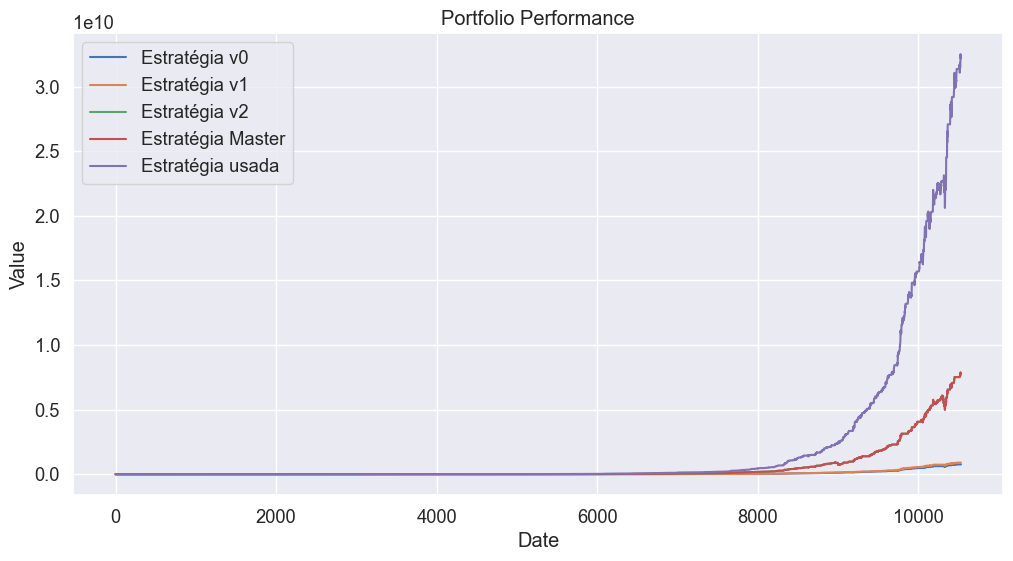

Estratégia v0: 758949092.08%
Estratégia v1: 896789521.56%
Estratégia v2: 7823866071.97%
Estratégia Master: 7823866071.97%
Estratégia Master Testada: 32331944030.52%


In [ ]:
# Implementar todas as estratégias
pred_days = 30
label_data_v0 = dataGen_inference.label_data_v0(close_prices=data['Close'].values, window=pred_days)
label_data_v1 = dataGen_inference.label_data_v1(close_prices=data['Close'].values, window=pred_days)
label_data_v2 = dataGen_inference.label_data__(close_prices=data['Close'].values, window=pred_days)
label_data_master = dataGen_inference.label_data_master(close_prices=data['Close'].values, window=pred_days)
label_data = dataGen_inference.label_data(close_prices=data['Close'].values, window=pred_days)

# Convertar as labels em sinais de compra e venda
trade_signals_v0 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v0]
trade_signals_v1 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v1]
trade_signals_v2 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v2]
trade_signals_master = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_master]
trade_signals = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data]

# Realizar o backtest
backtester_v0 = Backtester(initial_balance, data)
backtester_v0.run(trade_signals_v0)

backtester_v1 = Backtester(initial_balance, data)
backtester_v1.run(trade_signals_v1)

backtester_v2 = Backtester(initial_balance, data)
backtester_v2.run(trade_signals_v2)

backtester_master = Backtester(initial_balance, data)
backtester_master.run(trade_signals_master)

backtester = Backtester(initial_balance, data)
backtester.run(trade_signals)

# Plotar os resultados
plt.figure(figsize=(12, 6))
plt.plot(backtester_v0.data.index, backtester_v0.portfolio_value, label='Estratégia v0')
plt.plot(backtester_v1.data.index, backtester_v1.portfolio_value, label='Estratégia v1')
plt.plot(backtester_v2.data.index, backtester_v2.portfolio_value, label='Estratégia v2')
plt.plot(backtester_master.data.index, backtester_master.portfolio_value, label='Estratégia Master')
plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia usada')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Portfolio Performance')
plt.legend()
plt.show()

# Calcular o retorno de cada estratégia
retorno_v0 = (backtester_v0.portfolio_value[-1] - initial_balance) / initial_balance
retorno_v1 = (backtester_v1.portfolio_value[-1] - initial_balance) / initial_balance
retorno_v2 = (backtester_v2.portfolio_value[-1] - initial_balance) / initial_balance
retorno_master = (backtester_master.portfolio_value[-1] - initial_balance) / initial_balance
retorno_master_tested = (backtester.portfolio_value[-1] - initial_balance) / initial_balance

# Imprimir os resultados
print(f"Estratégia v0: {retorno_v0 * 100:.2f}%")
print(f"Estratégia v1: {retorno_v1 * 100:.2f}%")
print(f"Estratégia v2: {retorno_v2 * 100:.2f}%")
print(f"Estratégia Master: {retorno_master * 100:.2f}%")
print(f"Estratégia Master Testada: {retorno_master_tested * 100:.2f}%")